In [1]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

2026-09-12 16:09:32.677947: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-12 16:09:32.869838: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789229372.910214    1837 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789229372.922310    1837 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789229373.059211    1837 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast,
    Flatten
)

from tensorflow.keras.regularizers import l2
from PIL import Image

In [3]:
with open("all.json", "r") as file:
    data = json.load(file)

In [4]:
X = []
y = []

In [5]:
for category in data:
    for image in data[category]:
        img = Image.open(f"./all/{image}")
        img = img.convert("RGB")
        img = img.resize((224, 224))
        img_array = np.array(img)
        X.append(img_array)
        y.append(category)

/home/shashi/miniconda3/envs/tensorflow/lib/python3.11/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [6]:
X = np.array(X)
y = np.array(y)

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [10]:
# First split: 80% training+validation, 20% testing
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)

print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Testing images:", X_test.shape)

print("\nNumber of classes:", len(encoder.classes_))
print("Classes:", encoder.classes_)

Training images: (7680, 224, 224, 3)
Validation images: (1920, 224, 224, 3)
Testing images: (2400, 224, 224, 3)

Number of classes: 2
Classes: [0 1]


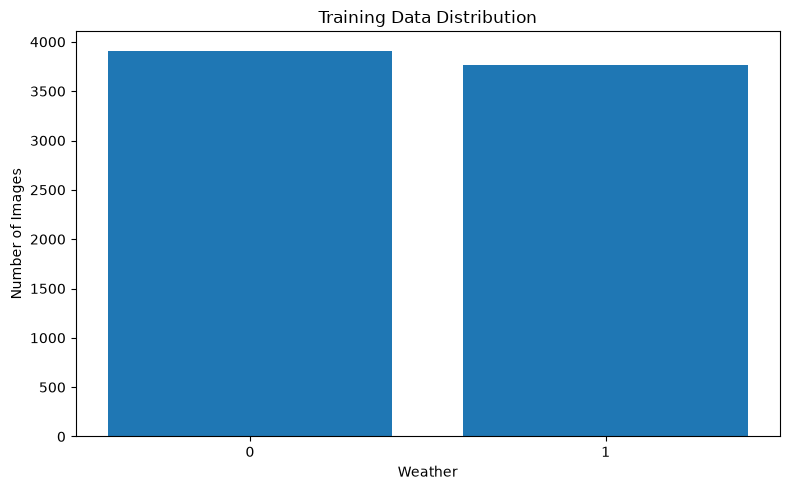

In [11]:
classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xlabel("Weather")
plt.ylabel("Number of Images")
plt.title("Training Data Distribution")
plt.tight_layout()
plt.xticks(classes)
plt.show()

In [12]:
num_classes = len(encoder.classes_)

model = Sequential([
    
    Input(shape=(224, 224, 3)),
    
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    GlobalAveragePooling2D(),
    
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.0001)
    ),
    
    Dropout(0.5),

    Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

I0000 00:00:1789229453.505930    1837 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,490 (1.62 MB)

 Trainable params: 422,530 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.000001
)

checkpoint = ModelCheckpoint(
    "best_weather_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    
    validation_data=(
        X_val,
        y_val
    ),
    
    epochs=30,
    
    batch_size=32,
    
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    
    verbose=1
)

In [18]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTesting Loss    :", test_loss)
print("Testing Accuracy:", test_accuracy)


Testing Loss    : 0.159392312169075
Testing Accuracy: 0.9616666436195374


In [19]:
y_pred_probability = model.predict(X_test)
y_pred = np.argmax(y_pred_probability, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


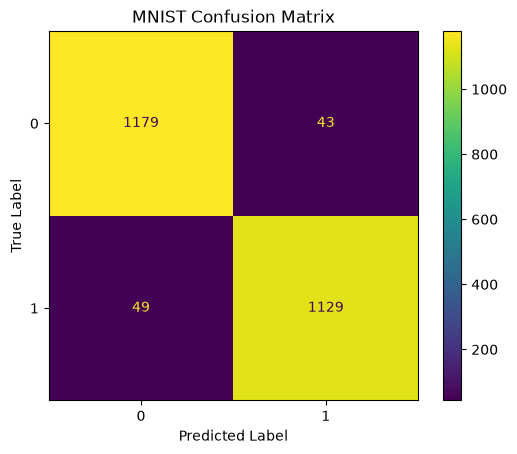

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()

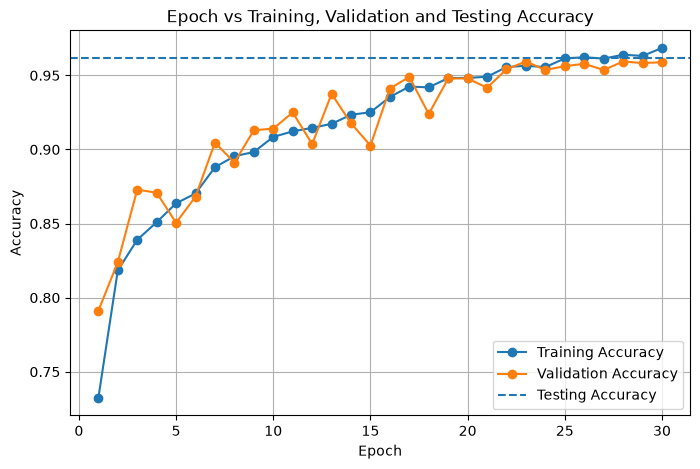

In [21]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axhline(
    test_accuracy,
    linestyle="--",
    label="Testing Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Epoch vs Training, Validation and Testing Accuracy")
plt.legend()
plt.grid(True)
plt.show()

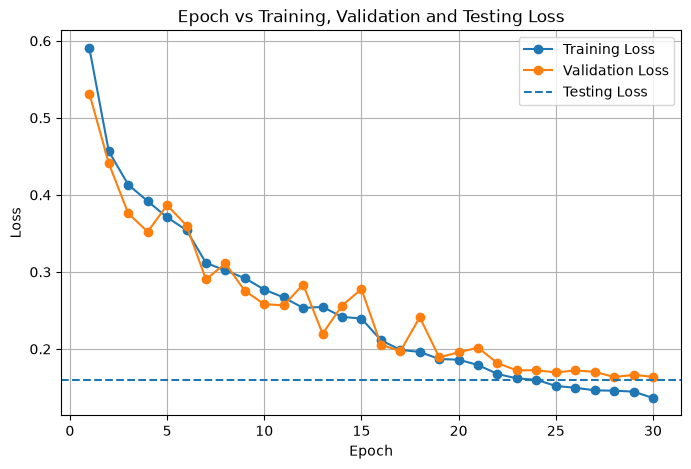

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axhline(
    test_loss,
    linestyle="--",
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Training, Validation and Testing Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
model.save("freshness-detection-cnn.keras")

In [24]:
!pip install tensorflowjs

  Using cached tensorflowjs-4.22.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached flax-0.12.8-py3-none-any.whl.metadata (11 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached jax-0.10.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.2-cp311-cp311-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow_decision_forests-1.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.3 kB)
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached wheel-0.46.2-py3-none-any.whl.m

In [26]:
model.save_weights('freshness-detection.weights.h5')

In [27]:
model.save('freshness-detection-dup.h5') 

In [28]:
!tensorflowjs_converter --input_format=keras freshness-detection-dup.h5 tfjs_model

2026-09-12 15:44:07.426950: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-12 15:44:07.541402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789227847.600087    4799 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789227847.617553    4799 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789227847.702947    4799 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 